- git status
- git add .
- git commit -m "describe changes"
- git push

PyMarketSim can be modified fairly quickly to use historical price data as the fundamental signal. However, simply replacing the mean-reverting fundamental is not enough; the agent-side parameters must also be recalibrated to the historical price scale. After recalibration, the model produces midprices that remain within a realistic range relative to the historical series.

reducing pv_var and zi_shade increases matched orders

set A loosest; set C most aggressive/highest trading; set B middle (not too sparse, not as hyperactive)

In [1]:
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kurtosis
from marketsim.simulator.simulator import Simulator
from marketsim.simulator.simulator_v2 import Simulator as Simulator2

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
def load_stockmarl_close_series(csv_path, ticker="AAPL"):
    raw = pd.read_csv(csv_path)

    # row 0 contains ticker labels
    ticker_row = raw.iloc[0]

    # actual data starts at row 2
    data = raw.iloc[2:].copy().reset_index(drop=True)

    # find the Close column for the requested ticker
    close_cols = [col for col in raw.columns if str(col).startswith("Close")]
    selected_col = None

    for col in close_cols:
        if ticker_row[col] == ticker:
            selected_col = col
            break

    if selected_col is None:
        raise ValueError(f"Could not find Close column for ticker {ticker}")

    prices = pd.to_numeric(data[selected_col], errors="coerce").dropna().to_numpy(dtype=float)
    return prices

In [3]:
csv_path = r"R:\sescott1\Masters\thesis\potential_codes\StockMARL\Stock-MARL-main\resources\datasets\train_dataV1.csv"
ticker = "AAPL"
sim_time = 500

historical_prices = load_stockmarl_close_series(csv_path, ticker=ticker)

print("Historical series length:", len(historical_prices))
print("First 10 prices:", historical_prices[:10])

Historical series length: 1761
First 10 prices: [28.87249947 28.75       28.10000038 28.53000069 27.98749924 27.90500069
 27.43250084 27.05750084 26.6875     27.35250092]


In [4]:
baseline_sim = Simulator(
    num_background_agents=50,
    sim_time=sim_time,
    num_assets=1,
    lam=0.1,
    mean=100.0,
    r=0.6,
    shock_var=10.0,
    q_max=10,
    pv_var=5e6,
    zi_shade=[10, 30],
    seed=SEED
)

baseline_sim.run()

baseline_market = baseline_sim.markets[0]
baseline_midprices = np.array(baseline_market.get_midprices(), dtype=float)
baseline_fundamental = np.array(
    [baseline_market.fundamental.get_value_at(t) for t in range(len(baseline_midprices))],
    dtype=float
)

print("Baseline matched orders:", len(baseline_market.matched_orders))
print("Baseline first 10 midprices:", baseline_midprices[:10])
print("Baseline first 10 fundamentals:", baseline_fundamental[:10])

Baseline matched orders: 144
Baseline first 10 midprices: [ 3.64454575e+01  1.21666716e+02  1.78450693e+02 -2.95641024e-02
 -2.95641024e-02 -2.95641024e-02 -1.00829356e+02 -1.00829356e+02
 -1.00829356e+02 -7.90485778e+01]
Baseline first 10 fundamentals: [100.         104.70320129 104.72960663  95.23360443 100.23879242
  96.19154358  98.34043121  94.26177216  95.32624817 103.34422302]


In [5]:
historical_sim = Simulator2(
    num_background_agents=50,
    sim_time=sim_time,
    num_assets=1,
    lam=0.1,
    q_max=10,
    pv_var=1.0,
    zi_shade=[0.05, 0.5],
    fundamental_type="historical",
    historical_prices=historical_prices,
    seed=SEED
)

historical_sim.run()

historical_market = historical_sim.markets[0]
historical_midprices = np.array(historical_market.get_midprices(), dtype=float)
historical_fundamental = np.array(
    [historical_market.fundamental.get_value_at(t) for t in range(len(historical_midprices))],
    dtype=float
)

print("Historical matched orders:", len(historical_market.matched_orders))
print("Historical first 10 midprices:", historical_midprices[:10])
print("Historical first 10 fundamentals:", historical_fundamental[:10])

Historical matched orders: 1072
Historical first 10 midprices: [28.66412856 28.27627911 28.53130715 28.28591441 28.17138114 28.00835571
 27.57354182 27.46739112 27.46400197 27.95421563]
Historical first 10 fundamentals: [28.87249947 28.75       28.10000038 28.53000069 27.98749924 27.90500069
 27.43250084 27.05750084 26.6875     27.35250092]


In [ ]:
baseline_rescaled_mean = float(np.mean(historical_prices[:sim_time+1]))

baseline_rescaled_sim = Simulator(
    num_background_agents=50,
    sim_time=sim_time,
    num_assets=1,
    lam=0.1,
    mean=baseline_rescaled_mean,
    r=0.6,
    shock_var=1.0,
    q_max=10,
    pv_var=1.0,
    zi_shade=[0.05, 0.5],
    seed=SEED
)

baseline_rescaled_sim.run()

baseline_rescaled_market = baseline_rescaled_sim.markets[0]
baseline_rescaled_midprices = np.array(baseline_rescaled_market.get_midprices(), dtype=float)
baseline_rescaled_fundamental = np.array(
    [baseline_rescaled_market.fundamental.get_value_at(t) for t in range(len(baseline_rescaled_midprices))],
    dtype=float
)

print("Baseline rescaled matched orders:", len(baseline_rescaled_market.matched_orders))
print("Baseline rescaled first 10 midprices:", baseline_rescaled_midprices[:10])
print("Baseline rescaled first 10 fundamentals:", baseline_rescaled_fundamental[:10])

Baseline rescaled matched orders: 56
Baseline rescaled first 10 midprices: [27.90983417 28.07092218 28.18023422 28.15198634 28.16676491 28.16676491
 28.11545944 28.11545944 28.11545944 28.11902516]
Baseline rescaled first 10 fundamentals: [28.05695534 29.54423714 29.55258369 26.54968452 28.13246536 26.85261345
 27.53215027 26.24236488 26.57898331 29.11449051]


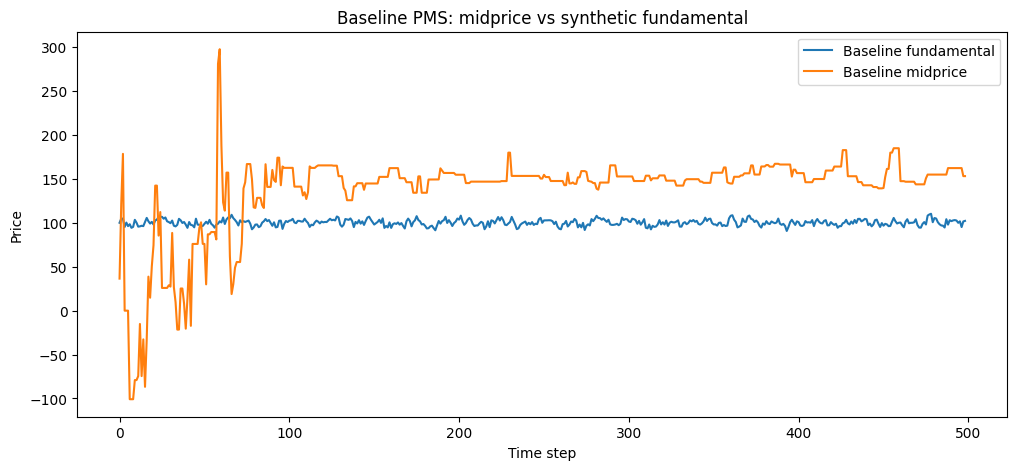

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(baseline_fundamental, label="Baseline fundamental")
plt.plot(baseline_midprices, label="Baseline midprice")
plt.title("Baseline PMS: midprice vs synthetic fundamental")
plt.xlabel("Time step")
plt.ylabel("Price")
plt.legend()
plt.show()

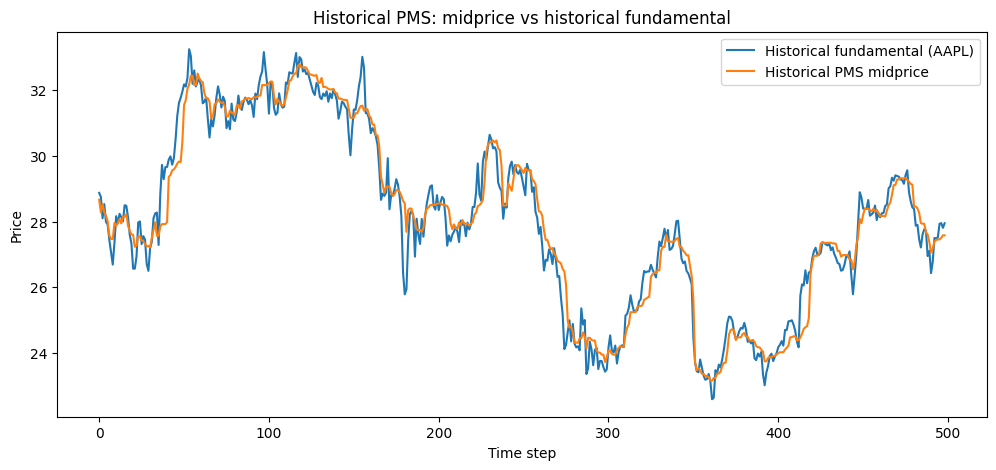

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(historical_fundamental, label=f"Historical fundamental ({ticker})")
plt.plot(historical_midprices, label="Historical PMS midprice")
plt.title("Historical PMS: midprice vs historical fundamental")
plt.xlabel("Time step")
plt.ylabel("Price")
plt.legend()
plt.show()

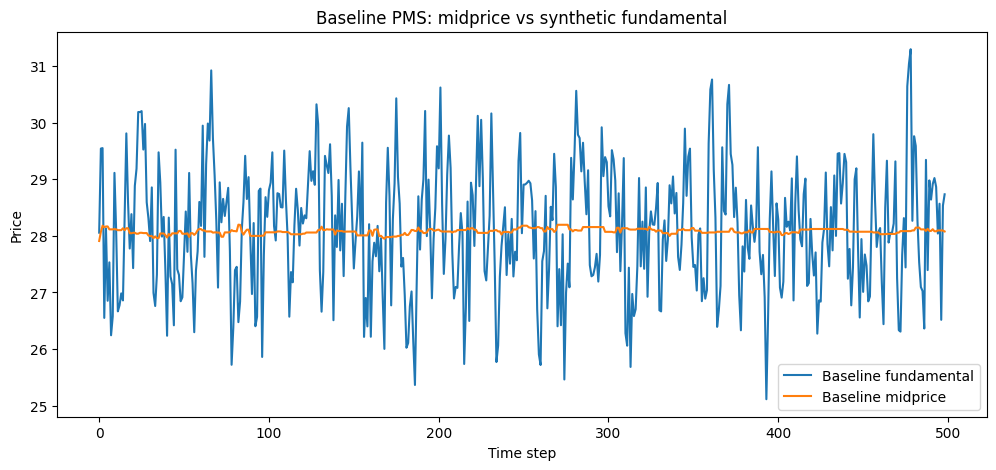

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(baseline_rescaled_fundamental, label="Baseline fundamental")
plt.plot(baseline_rescaled_midprices, label="Baseline midprice")
plt.title("Baseline PMS: midprice vs synthetic fundamental")
plt.xlabel("Time step")
plt.ylabel("Price")
plt.legend()
plt.show()

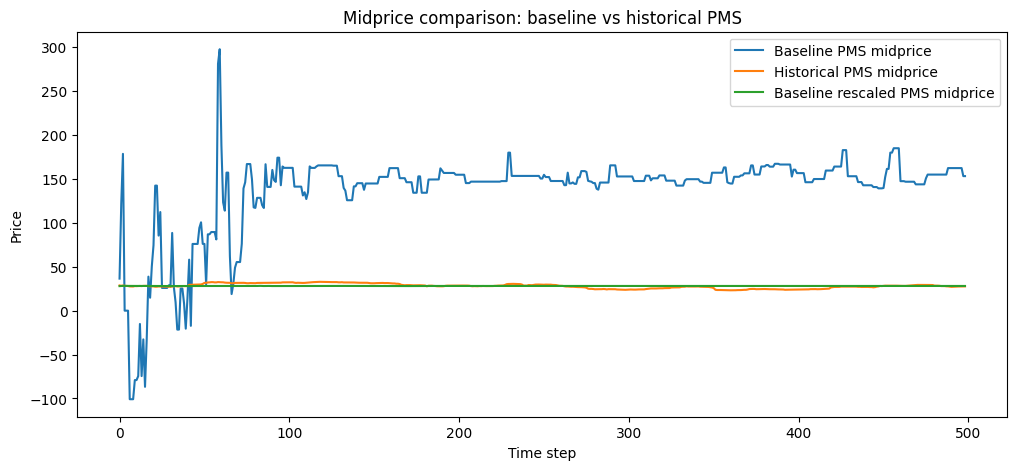

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(baseline_midprices, label="Baseline PMS midprice")
plt.plot(historical_midprices, label="Historical PMS midprice")
plt.plot(baseline_rescaled_midprices, label="Baseline rescaled PMS midprice")
plt.title("Midprice comparison: baseline vs historical PMS")
plt.xlabel("Time step")
plt.ylabel("Price")
plt.legend()
plt.show()

In [11]:
def compute_tracking_metrics(midprices, fundamental):
    errors = midprices - fundamental
    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors**2))
    corr = np.corrcoef(midprices, fundamental)[0, 1]
    error_std = np.std(errors)
    return {
        "mae": mae,
        "rmse": rmse,
        "corr": corr,
        "error_std": error_std
    }

def simple_returns(price_series):
    price_series = np.asarray(price_series, dtype=float)
    return np.diff(price_series) / price_series[:-1]

def log_returns(price_series):
    price_series = np.asarray(price_series, dtype=float)
    return np.diff(np.log(price_series))

def lag1_autocorr(x):
    x = np.asarray(x, dtype=float)
    if len(x) < 2:
        return np.nan
    return np.corrcoef(x[:-1], x[1:])[0, 1]

In [12]:
baseline_tracking = compute_tracking_metrics(baseline_midprices, baseline_fundamental)
historical_tracking = compute_tracking_metrics(historical_midprices, historical_fundamental)
baseline_rescaled_tracking = compute_tracking_metrics(baseline_rescaled_midprices, baseline_rescaled_fundamental)

tracking_df = pd.DataFrame([baseline_tracking, historical_tracking, baseline_rescaled_tracking], index=["Baseline PMS", "Historical PMS", "Baseline Rescaled PMS"])
tracking_df

,mae,rmse,corr,error_std
Baseline PMS,55.067243,60.523340,0.038559,48.278410
Historical PMS,0.381885,0.546787,0.979736,0.546689
Baseline Rescaled PMS,0.901483,1.104464,-0.050371,1.103741


In [13]:
baseline_ret = log_returns(baseline_midprices)
historical_ret = log_returns(historical_midprices)
baseline_rescaled_ret = log_returns(baseline_rescaled_midprices)

baseline_sq_acf1 = lag1_autocorr(baseline_ret**2)
historical_sq_acf1 = lag1_autocorr(historical_ret**2)
baseline_rescaled_sq_acf1 = lag1_autocorr(baseline_rescaled_ret**2)

baseline_abs_acf1 = lag1_autocorr(np.abs(baseline_ret))
historical_abs_acf1 = lag1_autocorr(np.abs(historical_ret))
baseline_rescaled_abs_acf1 = lag1_autocorr(np.abs(baseline_rescaled_ret))

metrics_df = pd.DataFrame({
    "n_returns": [len(baseline_ret), len(historical_ret), len(baseline_rescaled_ret)],
    "mean_return": [np.mean(baseline_ret), np.mean(historical_ret), np.mean(baseline_rescaled_ret)],
    "std_return": [np.std(baseline_ret), np.std(historical_ret), np.std(baseline_rescaled_ret)],
    "kurtosis": [kurtosis(baseline_ret, fisher=False), kurtosis(historical_ret, fisher=False), kurtosis(baseline_rescaled_ret, fisher=False)],
    "lag1_acf_squared_returns": [baseline_sq_acf1, historical_sq_acf1, baseline_rescaled_sq_acf1],
    "lag1_acf_abs_returns": [baseline_abs_acf1, historical_abs_acf1, baseline_rescaled_abs_acf1],
    "matched_orders": [len(baseline_market.matched_orders), len(historical_market.matched_orders), len(baseline_rescaled_market.matched_orders)]
}, index=["Baseline PMS", "Historical PMS", "Baseline Rescaled PMS"])

metrics_df

C:\Users\sescott1\AppData\Local\Temp\ipykernel_81684\3471221883.py:20: RuntimeWarning: invalid value encountered in log
  return np.diff(np.log(price_series))


,n_returns,mean_return,std_return,kurtosis,lag1_acf_squared_returns,lag1_acf_abs_returns,matched_orders
Baseline PMS,498,NaN,NaN,NaN,NaN,NaN,144
Historical PMS,498,-0.000078,0.008787,22.057958,0.102347,0.218043,1072
Baseline Rescaled PMS,498,0.000012,0.001011,9.026748,0.168839,0.084866,56


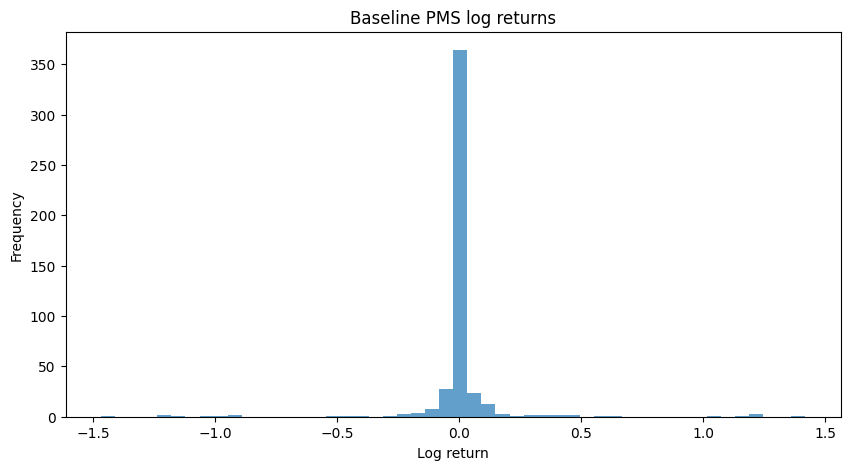

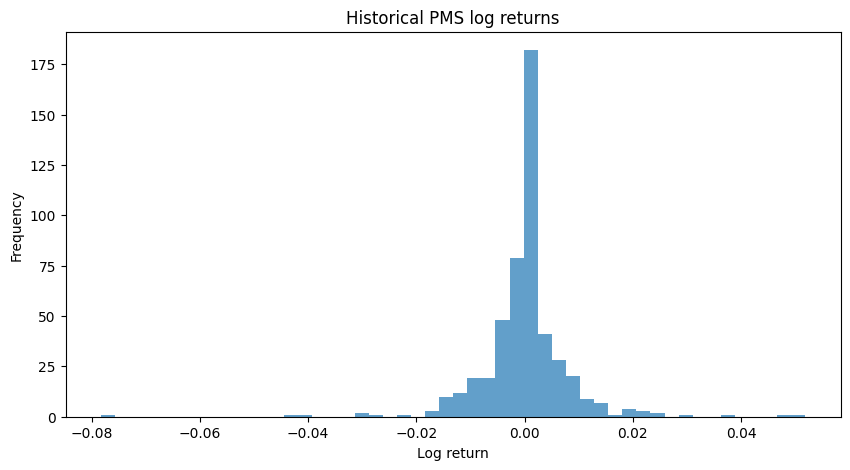

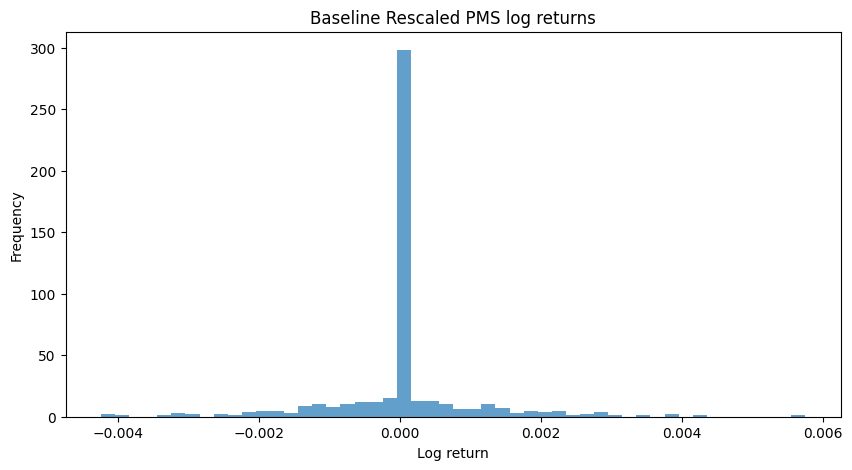

In [14]:
plt.figure(figsize=(10, 5))
plt.hist(baseline_ret, bins=50, alpha=0.7)
plt.title("Baseline PMS log returns")
plt.xlabel("Log return")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(historical_ret, bins=50, alpha=0.7)
plt.title("Historical PMS log returns")
plt.xlabel("Log return")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(baseline_rescaled_ret, bins=50, alpha=0.7)
plt.title("Baseline Rescaled PMS log returns")
plt.xlabel("Log return")
plt.ylabel("Frequency")
plt.show()

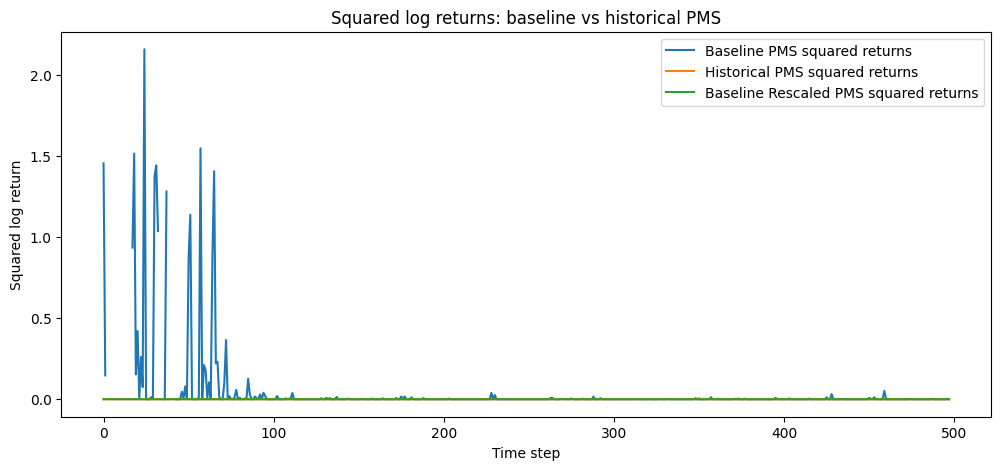

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(baseline_ret**2, label="Baseline PMS squared returns")
plt.plot(historical_ret**2, label="Historical PMS squared returns")
plt.plot(baseline_rescaled_ret**2, label="Baseline Rescaled PMS squared returns")
plt.title("Squared log returns: baseline vs historical PMS")
plt.xlabel("Time step")
plt.ylabel("Squared log return")
plt.legend()
plt.show()

In [16]:
print("Tracking metrics")
print(tracking_df)
print("\nReturns / realism-style metrics")
print(metrics_df)

Tracking metrics
                             mae       rmse      corr  error_std
Baseline PMS           55.067243  60.523340  0.038559  48.278410
Historical PMS          0.381885   0.546787  0.979736   0.546689
Baseline Rescaled PMS   0.901483   1.104464 -0.050371   1.103741

Returns / realism-style metrics
                       n_returns  mean_return  std_return   kurtosis  \
Baseline PMS                 498          NaN         NaN        NaN   
Historical PMS               498    -0.000078    0.008787  22.057958   
Baseline Rescaled PMS        498     0.000012    0.001011   9.026748   

                       lag1_acf_squared_returns  lag1_acf_abs_returns  \
Baseline PMS                                NaN                   NaN   
Historical PMS                         0.102347              0.218043   
Baseline Rescaled PMS                  0.168839              0.084866   

                       matched_orders  
Baseline PMS                      144  
Historical PMS              

Replacing PyMarketSim’s default mean-reverting fundamental with a historical price series was feasible with relatively modest code changes. After recalibrating the agent-side parameters to the historical price scale, the modified model produced midprices that closely tracked the historical underlying series, substantially outperforming both the original and rescaled synthetic-fundamental versions on MAE, RMSE, and correlation. However, the modification also changed higher-order return behavior: while the historical version retained heavy tails, it exhibited weaker volatility clustering than the synthetic baselines.

In [17]:
real_prices = np.asarray(historical_prices[:sim_time + 1], dtype=float)

# align to the same effective length as historical PMS if needed
real_n = min(len(real_prices), len(historical_midprices))
real_prices = real_prices[:real_n]
historical_midprices_aligned = historical_midprices[:real_n]
historical_fundamental_aligned = historical_fundamental[:real_n]

print("Real historical length:", len(real_prices))
print("Historical PMS aligned length:", len(historical_midprices_aligned))
print("First 10 real prices:", real_prices[:10])

Real historical length: 499
Historical PMS aligned length: 499
First 10 real prices: [28.87249947 28.75       28.10000038 28.53000069 27.98749924 27.90500069
 27.43250084 27.05750084 26.6875     27.35250092]


In [18]:
def compare_to_real(sim_prices, real_prices):
    sim_prices = np.asarray(sim_prices, dtype=float)
    real_prices = np.asarray(real_prices, dtype=float)
    n = min(len(sim_prices), len(real_prices))
    sim_prices = sim_prices[:n]
    real_prices = real_prices[:n]

    errors = sim_prices - real_prices
    return {
        "mae_vs_real": np.mean(np.abs(errors)),
        "rmse_vs_real": np.sqrt(np.mean(errors**2)),
        "corr_vs_real": np.corrcoef(sim_prices, real_prices)[0, 1],
        "error_std_vs_real": np.std(errors),
    }

In [19]:
baseline_vs_real = compare_to_real(baseline_midprices, real_prices)
historical_vs_real = compare_to_real(historical_midprices_aligned, real_prices)
baseline_rescaled_vs_real = compare_to_real(baseline_rescaled_midprices, real_prices)

vs_real_df = pd.DataFrame(
    [baseline_vs_real, historical_vs_real, baseline_rescaled_vs_real],
    index=["Baseline PMS", "Historical PMS", "Baseline Rescaled PMS"]
)

vs_real_df

,mae_vs_real,rmse_vs_real,corr_vs_real,error_std_vs_real
Baseline PMS,114.506420,119.040136,-0.104634,48.648040
Historical PMS,0.381885,0.546787,0.979736,0.546689
Baseline Rescaled PMS,2.250261,2.740926,-0.308094,2.740825


In [20]:
real_ret = log_returns(real_prices)

real_metrics = pd.DataFrame({
    "n_returns": [len(real_ret)],
    "mean_return": [np.mean(real_ret)],
    "std_return": [np.std(real_ret)],
    "kurtosis": [kurtosis(real_ret, fisher=False)],
    "lag1_acf_squared_returns": [lag1_autocorr(real_ret**2)],
    "lag1_acf_abs_returns": [lag1_autocorr(np.abs(real_ret))]
}, index=["Actual Historical"])
real_metrics

,n_returns,mean_return,std_return,kurtosis,lag1_acf_squared_returns,lag1_acf_abs_returns
Actual Historical,498,-0.000065,0.016086,5.231944,0.100452,0.127232


In [32]:
comparison_with_real_df = pd.concat([real_metrics, metrics_df.loc[["Historical PMS", "Baseline Rescaled PMS", "Baseline PMS"]]], axis=0)

comparison_with_real_df

,n_returns,mean_return,std_return,kurtosis,lag1_acf_squared_returns,lag1_acf_abs_returns,matched_orders
Actual Historical,498,-0.000065,0.016086,5.231944,0.100452,0.127232,NaN
Historical PMS,498,-0.000078,0.008787,22.057958,0.102347,0.218043,1072.0
Baseline Rescaled PMS,498,0.000012,0.001011,9.026748,0.168839,0.084866,56.0
Baseline PMS,498,NaN,NaN,NaN,NaN,NaN,144.0


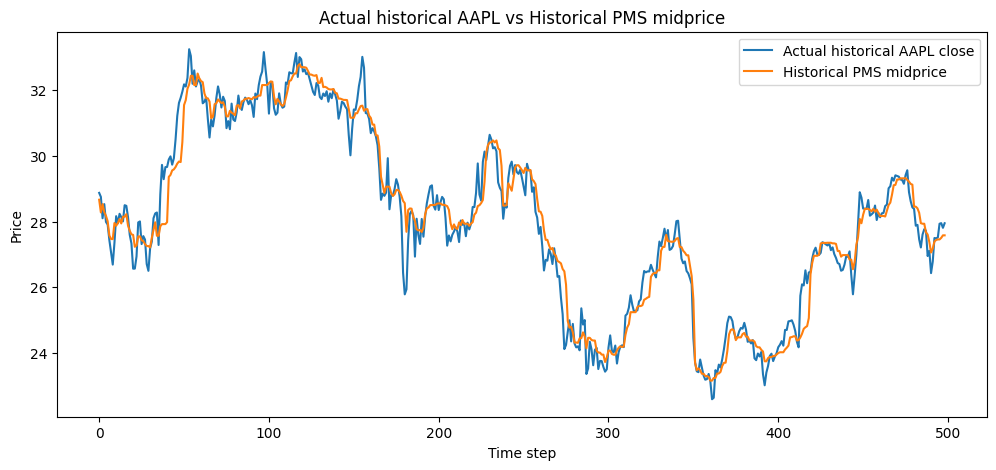

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(real_prices, label=f"Actual historical {ticker} close")
plt.plot(historical_midprices_aligned, label="Historical PMS midprice")
plt.title(f"Actual historical {ticker} vs Historical PMS midprice")
plt.xlabel("Time step")
plt.ylabel("Price")
plt.legend()
plt.show()

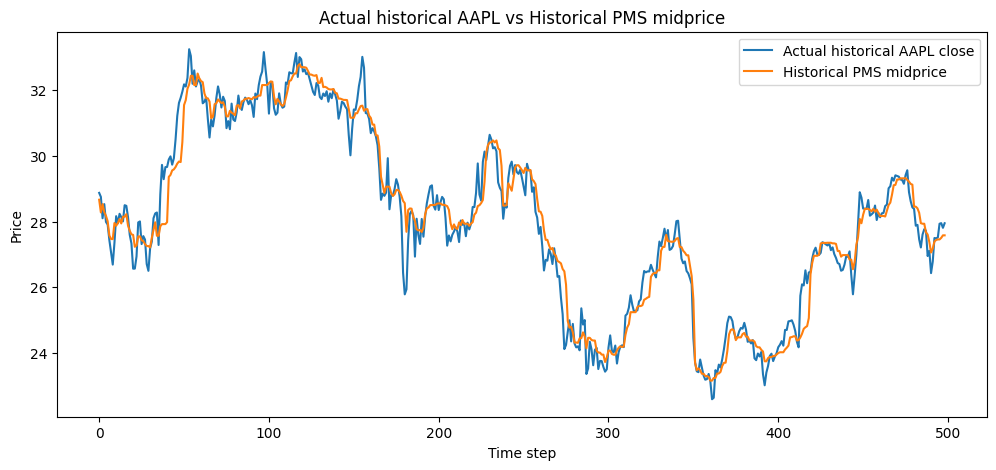

In [23]:
plt.figure(figsize=(12, 5))
plt.plot(real_prices, label=f"Actual historical {ticker} close")
plt.plot(historical_midprices_aligned, label="Historical PMS midprice")
plt.title(f"Actual historical {ticker} vs Historical PMS midprice")
plt.xlabel("Time step")
plt.ylabel("Price")
plt.legend()
plt.show()

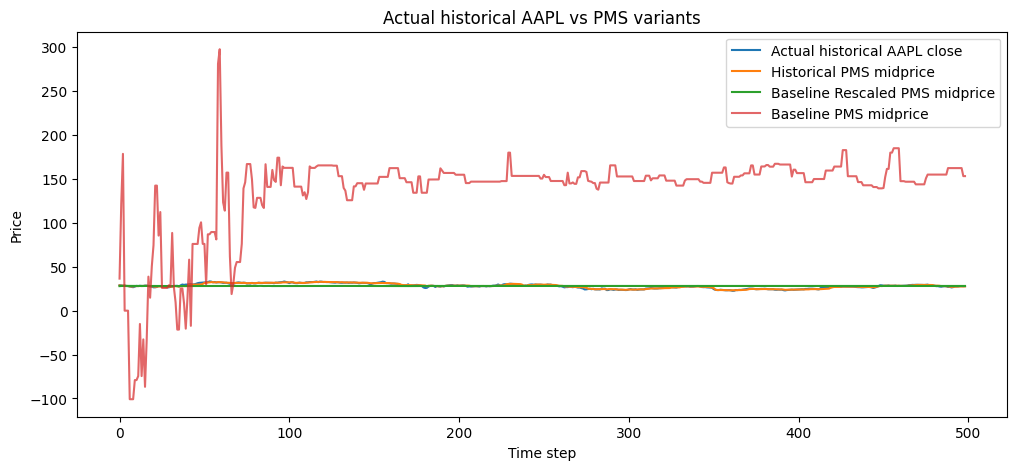

In [24]:
n_plot = min(len(real_prices), len(baseline_midprices), len(baseline_rescaled_midprices), len(historical_midprices_aligned))

plt.figure(figsize=(12, 5))
plt.plot(real_prices[:n_plot], label=f"Actual historical {ticker} close")
plt.plot(historical_midprices_aligned[:n_plot], label="Historical PMS midprice")
plt.plot(baseline_rescaled_midprices[:n_plot], label="Baseline Rescaled PMS midprice")
plt.plot(baseline_midprices[:n_plot], label="Baseline PMS midprice", alpha=0.7)
plt.title(f"Actual historical {ticker} vs PMS variants")
plt.xlabel("Time step")
plt.ylabel("Price")
plt.legend()
plt.show()

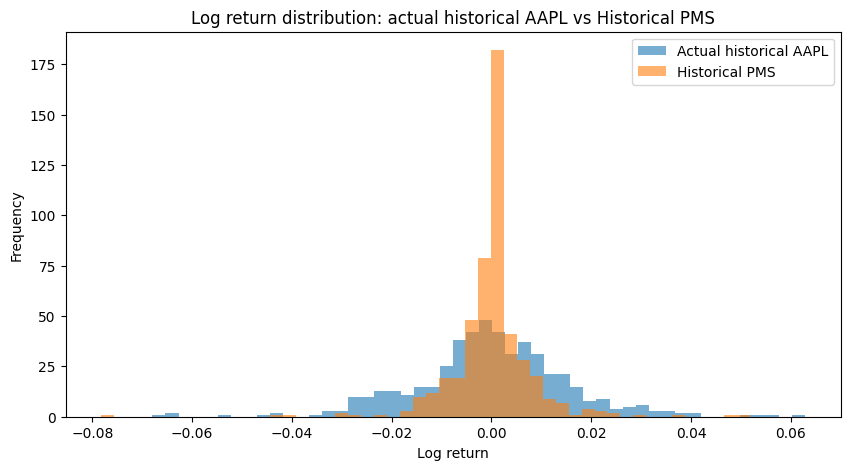

In [25]:
plt.figure(figsize=(10, 5))
plt.hist(real_ret, bins=50, alpha=0.6, label=f"Actual historical {ticker}")
plt.hist(historical_ret[:len(real_ret)], bins=50, alpha=0.6, label="Historical PMS")
plt.title(f"Log return distribution: actual historical {ticker} vs Historical PMS")
plt.xlabel("Log return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

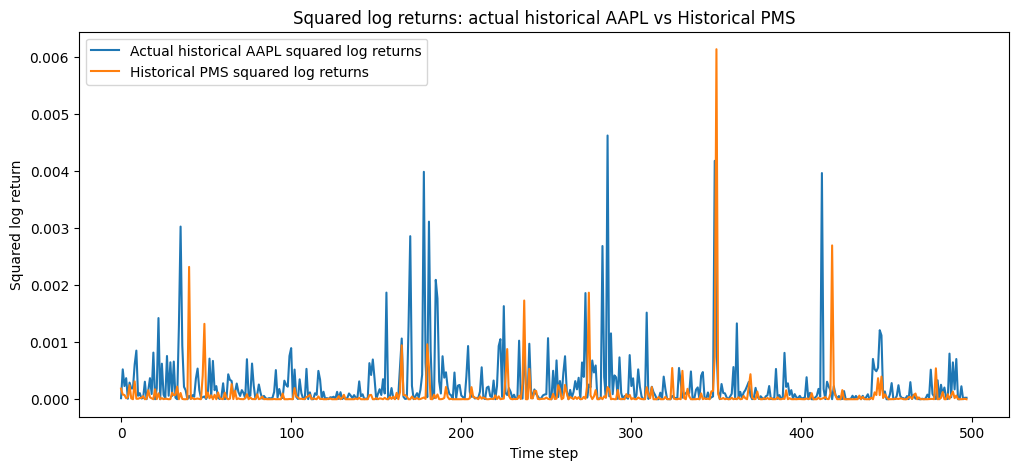

In [26]:
n_sq = min(len(real_ret), len(historical_ret))

plt.figure(figsize=(12, 5))
plt.plot(real_ret[:n_sq]**2, label=f"Actual historical {ticker} squared log returns")
plt.plot(historical_ret[:n_sq]**2, label="Historical PMS squared log returns")
plt.title(f"Squared log returns: actual historical {ticker} vs Historical PMS")
plt.xlabel("Time step")
plt.ylabel("Squared log return")
plt.legend()
plt.show()

In [ ]:
summary_df = pd.concat([vs_real_df, comparison_with_real_df], axis=1)
summary_df

,mae_vs_real,rmse_vs_real,corr_vs_real,error_std_vs_real,n_returns,mean_return,std_return,kurtosis,lag1_acf_squared_returns,lag1_acf_abs_returns,matched_orders
Baseline PMS,114.506420,119.040136,-0.104634,48.648040,498,NaN,NaN,NaN,NaN,NaN,144.0
Historical PMS,0.381885,0.546787,0.979736,0.546689,498,-0.000078,0.008787,22.057958,0.102347,0.218043,1072.0
Baseline Rescaled PMS,2.250261,2.740926,-0.308094,2.740825,498,0.000012,0.001011,9.026748,0.168839,0.084866,56.0
Actual Historical,NaN,NaN,NaN,NaN,498,-0.000065,0.016086,5.231944,0.100452,0.127232,NaN


In [28]:
print("Comparison of PMS variants against actual historical prices")
print(vs_real_df)

print("\nStylized-fact-style metrics for actual historical data and PMS variants")
print(comparison_with_real_df)

Comparison of PMS variants against actual historical prices
                       mae_vs_real  rmse_vs_real  corr_vs_real  \
Baseline PMS            114.506420    119.040136     -0.104634   
Historical PMS            0.381885      0.546787      0.979736   
Baseline Rescaled PMS     2.250261      2.740926     -0.308094   

                       error_std_vs_real  
Baseline PMS                   48.648040  
Historical PMS                  0.546689  
Baseline Rescaled PMS           2.740825  

Stylized-fact-style metrics for actual historical data and PMS variants
                       n_returns  mean_return  std_return   kurtosis  \
Actual Historical            498    -0.000065    0.016086   5.231944   
Historical PMS               498    -0.000078    0.008787  22.057958   
Baseline Rescaled PMS        498     0.000012    0.001011   9.026748   
Baseline PMS                 498          NaN         NaN        NaN   

                       lag1_acf_squared_returns  lag1_acf_abs_returns

In [29]:
baseline_vs_real = compare_to_real(baseline_midprices, real_prices)
historical_vs_real = compare_to_real(historical_midprices_aligned, real_prices)
baseline_rescaled_vs_real = compare_to_real(baseline_rescaled_midprices, real_prices)

vs_real_df = pd.DataFrame(
    [baseline_vs_real, historical_vs_real, baseline_rescaled_vs_real],
    index=["Baseline PMS", "Historical PMS", "Baseline Rescaled PMS"]
)

vs_real_df

,mae_vs_real,rmse_vs_real,corr_vs_real,error_std_vs_real
Baseline PMS,114.506420,119.040136,-0.104634,48.648040
Historical PMS,0.381885,0.546787,0.979736,0.546689
Baseline Rescaled PMS,2.250261,2.740926,-0.308094,2.740825


In [ ]:
comparison_with_real_df = pd.concat([real_metrics, metrics_df.loc[["Historical PMS", "Baseline Rescaled PMS", "Baseline PMS"]]], axis=0)
comparison_with_real_df

,n_returns,mean_return,std_return,kurtosis,lag1_acf_squared_returns,lag1_acf_abs_returns,matched_orders
Actual Historical,498,-0.000065,0.016086,5.231944,0.100452,0.127232,NaN
Historical PMS,498,-0.000078,0.008787,22.057958,0.102347,0.218043,1072.0
Baseline Rescaled PMS,498,0.000012,0.001011,9.026748,0.168839,0.084866,56.0
Baseline PMS,498,NaN,NaN,NaN,NaN,NaN,144.0
